# Create the Blog Generator workflow

In [7]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [8]:
model = ChatGroq(model="openai/gpt-oss-20b", api_key=os.getenv("GROK_API_KEY"))

In [9]:
# model.invoke("what is the criteria for clearing the JEE Exam").content

In [17]:
# Create a State
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: str

In [18]:
def get_gen_outline(state: BlogState) -> BlogState:
    # Get the title.
    title = state['title']

    # Prompt for the topic
    prompt = f'Give me the detailed report about {title}'

    # Get the answer
    answer = model.invoke(prompt).content

    # Update the state
    state['outline'] = answer

    # Return the state
    return state

In [19]:
def get_gen_blog(state: BlogState) ->  BlogState:
    # get the detailed outline of the topic.
    title = state['title']
    outline = state['outline']

    # Prompt for generating the blog
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    # Get the answer
    answer = model.invoke(prompt).content

    # Update the state
    state['content'] = answer

    # Return the state
    return state

In [20]:
def get_score(state: BlogState) -> BlogState:
    # get the score from the state.
    # score = state['score']
    content = state['content']
    outline = state['outline']

    # Prompt for generating the score.
    prompt = f"Evaluate my blog {content} based on the {outline} and return an integer score from 1 to 10 only."

    #Call the LLM.
    answer = model.invoke(prompt).content

    # Update the state
    state['score'] = answer

    # Return the state
    return state

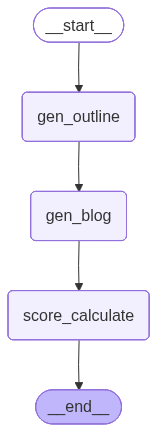

In [21]:
# Initialize the graph
graph = StateGraph(BlogState)


# Add nodes to the graph
graph.add_node('gen_outline', get_gen_outline)
graph.add_node('gen_blog', get_gen_blog)
graph.add_node('score_calculate', get_score)

# Add edges
graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', 'score_calculate')
graph.add_edge('score_calculate', END)

# Compile the graph
graph.compile()

In [22]:
workflow = graph.compile()

In [23]:
# Execute the graph flow.

initial_state = {"title": "HFT Arbitrage"}


final_output = workflow.invoke(initial_state)

print(final_output['content'])

# High‑Frequency Trading (HFT) Arbitrage  
*A comprehensive technical & regulatory report (Jan 2025)*  

---

## 1. Executive Summary  

High‑frequency trading (HFT) arbitrage is the art of catching price discrepancies that exist for only milliseconds—or even microseconds—across markets, instruments, or data feeds. By automating the entire lifecycle—data ingestion → signal generation → order placement → execution → risk monitoring—HFT arbitrage firms generate consistent, low‑margin profits from very small price differentials.  

**Key take‑aways**

| Topic | Core Insight |
|-------|--------------|
| **Profitability** | Average daily gross profit ≈ $5–$15 billion (global) – but net profit after costs ≈ $1–$3 billion. |
| **Speed is king** | Millisecond‑level latency (including 10‑20 µs network, 1‑2 µs hardware, 1–5 µs broker API) is the main competitive edge. |
| **Market impact** | HFT arbitrage contributes ~15–25 % of total daily U.S. equity volume; it can both improve liquidity and c

In [24]:
workflow.invoke(initial_state)

{'title': 'HFT Arbitrage',
 'outline': '# High‑Frequency Trading (HFT) Arbitrage – Detailed Report\n\n> **Audience**: Quantitative researchers, algorithmic traders, risk managers, compliance officers, and academic scholars.  \n> **Scope**: The report covers the technical, market‑microstructure, regulatory, and risk aspects of arbitrage strategies that are typically executed by high‑frequency trading (HFT) firms.  \n\n---\n\n## 1. Executive Summary\n\n- **HFT arbitrage** refers to ultra‑low‑latency trading strategies that exploit fleeting price discrepancies across markets, instruments, or time‑frames.\n- Typical arbitrage categories:\n  1. **Cross‑market (inter‑exchange) arbitrage** – e.g., NYSE ↔ NASDAQ, CME ↔ Euronext.\n  2. **Cross‑asset (intra‑market) arbitrage** – e.g., futures vs. spot, ETFs vs. underlying indices.\n  3. **Statistical/mean‑reversion arbitrage** – e.g., pairs trading, index‑basket arbitrage.\n  4. **Latency‑based (news/quote‑driven) arbitrage** – e.g., reacting to